# PDAN8412 PART 1

# Long-Term Short-Term Recurrent Neural Network Analysis
    
This notebook performs Long-Term Short-Term Recurrent Neural Network

# Recurent Neural Network:

**What is a Recurrent Neural Network?**

Recurrent Neural Networks (RNNs) are a specific type of artificial neural network designed to handle sequences of data. Unlike traditional feedforward neural networks that function simply from input to output, RNNs have a unique feature: a feedback loop (Wikipedia Contributors, 2018). This feedback loop allows RNNs to keep a hidden state that holds information from previous time steps or elements in the sequence. This ability makes RNNs especially suitable for tasks involving sequences, like natural language processing, speech recognition, time series analysis, and more (GeeksforGeeks, 2018).

A major issue with basic RNNs is the vanishing gradient problem. During training, as gradients are sent backward through time, they often decrease exponentially as they go through multiple time steps. As a result, the model finds it hard to capture long-term dependencies in the data, leading to poor training and limited modeling ability (GeeksforGeeks, 2018). To solve this problem, Long Short-Term Memory (LSTM) networks were created. LSTMs have a more complex memory cell structure that can store, read, and write information to the hidden state. This advanced design enables LSTMs to effectively capture long-term dependencies in sequential data, using three main gates: the input gate, forget gate, and output gate, which control the flow of information in and out of the memory cell (Wikipedia Contributors, 2018).

Another important RNN variant is the Gated Recurrent Unit (GRU). GRUs were created as an alternative to tackle the vanishing gradient problem while keeping computational efficiency compared to LSTMs. GRUs simplify the architecture by merging the hidden state and memory cell into one vector and adding two key gates: the reset gate and update gate (GeeksforGeeks, 2018). The reset gate decides which parts of the previous hidden state need to be forgotten, while the update gate manages how much of the new candidate state should be added to the hidden state (Seed, 2021).

### Why is this dataset appropriate?

Source: https://www.kaggle.com/competitions/spooky-author-identification/data 

Data Features:

id - a unique identifier for each sentence

text - some text written by one of the authors

author - the author of the sentence (EAP: Edgar Allan Poe, HPL: HP Lovecraft; MWS: Mary Wollstonecraft Shelley)

It’s a perfect fit because it directly matches the goal: predicting an author from writing style. The dataset is large (19579 entries) and comfortably meets the “>10 000 entries” requirement while being reasonably balanced across the three authors, so models can learn without class bias. The texts are short passages that show stylistic hints—exactly what RNN/LSTM models are good at—yet they’re relatively clean, English, and easy to tokenise, so preprocessing is straightforward. It’s a well-known Kaggle dataset with clear labels and a standard train/test split, which makes results reproducible and comparisons fair. The CSV format works nicely with Spark for EDA and with Keras for text preprocessing and training. Overall, it’s big enough to be meaningful, focused enough to be tractable, and perfectly aligned with the author-guessing task.


### Justification of Algorithm used?

The chosen algorithm for this analysis is a Long Short-Term Memory (LSTM) network. LSTMs are designed for sequence data, which fits writing style because word choice, punctuation, and phrasing develop over time. The LSTM gating mechanism helps them keep useful context and avoid the “fading memory” problem seen in simple RNNs (Olah, 2015).

Implementinng the model with Keras/TensorFlow because it provides a clear, reproducible text pipeline—tokenise the sentence, map tokens to embeddings, pass them through an (bi-)LSTM, and use a softmax layer to choose the most likely author—following standard text-classification practice (TensorFlow, 2024).

This algorithm is justified for several reasons:

- Captures style over time – LSTMs retain long-range patterns in phrasing and punctuation that help distinguish authors (Olah, 2015).

- Practical and reproducible – Keras enables a simple end-to-end setup (tokenisation → embeddings → LSTM → softmax) that is easy to tune and deploy (TensorFlow, 2024).


### Steps:
**1. Import the libraries**

- Loaded pandas/numpy (data), matplotlib/seaborn (plots), scikit-learn (splits/metrics), TensorFlow/Keras (model + text prep), PySpark (SparkSession, functions, ml.feature).

**2.Load dataset**

- Installed the Kaggle API and used it to download the Spam Email Detection Dataset annd Unzipped the dataset for use.

- Read train.csv (Spooky Author Identification) and inspected shape/dtypes/head.

- Removed obvious issues (duplicates/blank text) and kept authors EAP, HPL, MWS.

**3. Start Spark Session**

- Created SparkSession('AuthorID') and loaded the CSV with header=True, inferSchema=True.

- Fixed header-as-row if present and cached the DataFrame for faster EDA.

**4. Exploratory Data Analysis (EDA)**

- Checked class balance and text length (chars/trimmed).

- Lower-cased text; tokenised and removed stopwords in Spark to view common tokens by author.

- Converted to pandas for quick plots (e.g., author distribution).

**5. Train/Test Split**

- Built labels in Spark (author_label: EAP=0, HPL=1, MWS=2) and moved to pandas.

- Performed an 80/20 split with a fixed random state to keep results reproducible.

**6. Text Pre-Processing**

- Used Keras Tokenizer (fit on train only) to convert text → integer sequences.

- Applied pad_sequences to a fixed length for uniform inputs; saved tokenizer/label map.

**7. Training and Building Model**

- Trained two baselines in Keras: a simple embedding/pooling model and an LSTM model (Embedding → (Spatial)Dropout → LSTM → Dense).

- Compiled with sparse_categorical_crossentropy and used EarlyStopping (and LR scheduling/checkpointing where shown).

**8. Evaluation**

- Generated predictions on the test set; computed accuracy, precision, recall, macro-F1, log-loss.

- Printed classification_report (per-class metrics) and compared RNN vs LSTM runs.

**9. Prediction**

- Demo’d single-text: tokenise/pad a sample sentence and call model.predict to return the most likely author (with probabilities).

## Long-Term Short-Term Recurrent Neural Network Analysis

Kernal: spark311 (Python 3.11.13)

Operating system: Mac iOS.

Sections:

1. Import The libraries
2. Load Dataset
3. Start the Spark Session
4. EDA
5. Train/Test Split
6. Text Pre-Processing
7. Training and Building Model 
8. Evaluation
9. Prediction
10. Conclusion
11. Reference List

# Import the libraries

In [1]:
# Load, explore and plot data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import  STOPWORDS
import plotly. express as px
import plotly.graph_objects as go
%matplotlib inline

# Train, Test Split
from sklearn.model_selection import train_test_split

# Text Pre-processing
import string
from sklearn.feature_extraction.text import CountVectorizer
import tensorflow as tf
import os, re, textwrap, random, warnings, string
from pyspark.ml.feature import Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))

# Modeling
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, GRU, Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalAveragePooling1D, Flatten, SpatialDropout1D
from tensorflow.keras.optimizers import Adam

2025-10-02 10:28:16.769157: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/calvinstott/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Load Dataset

In [2]:
pip install spark

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pyspark

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Access the Kaggle API
!pip install kaggle

In [5]:
# Download the dataset from Kaggle
!kaggle competitions download -c spooky-author-identification

spooky-author-identification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [6]:
# Unzipping the file to access the dataset.
!tar -xf "spooky-author-identification.zip"
!tar -xf "train.zip"

# Spark Session

In [7]:
from pyspark.sql import SparkSession
from pyspark import SparkConf
from pyspark import SparkContext
from pyspark.sql.functions import col, udf
from pyspark.ml.feature import Tokenizer, StopWordsRemover
from pyspark.ml import Pipeline
from pyspark.sql import functions as F

In [8]:
spark = SparkSession.builder.appName('AuthorID').getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/02 10:31:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [9]:
df = spark.read.csv('train.csv', header=True, inferSchema=True)

In [10]:
spark 

In [11]:
# Data Overview
df.printSchema()

root
 |-- id: string (nullable = true)
 |-- text: string (nullable = true)
 |-- author: string (nullable = true)



In [12]:
df.show(10)

+-------+--------------------+------+
|     id|                text|author|
+-------+--------------------+------+
|id26305|This process, how...|   EAP|
|id17569|It never once occ...|   HPL|
|id11008|In his left hand ...|   EAP|
|id27763|How lovely is spr...|   MWS|
|id12958|Finding nothing e...|   HPL|
|id22965|A youth passed in...|   MWS|
|id09674|The astronomer, p...|   EAP|
|id13515|The surcingle hun...|   EAP|
|id19322|I knew that you c...|   EAP|
|id00912|I confess that ne...|   MWS|
+-------+--------------------+------+
only showing top 10 rows



In [13]:
# The Shape of my dataset. Rows and Columnns
df.count(), len(df.columns)

(19579, 3)

In [14]:
# Dropping the id column
df_clean = df.drop('id')

In [15]:
df_clean.show(10)

+--------------------+------+
|                text|author|
+--------------------+------+
|This process, how...|   EAP|
|It never once occ...|   HPL|
|In his left hand ...|   EAP|
|How lovely is spr...|   MWS|
|Finding nothing e...|   HPL|
|A youth passed in...|   MWS|
|The astronomer, p...|   EAP|
|The surcingle hun...|   EAP|
|I knew that you c...|   EAP|
|I confess that ne...|   MWS|
+--------------------+------+
only showing top 10 rows



In [16]:
# Seeinng the how many duplicate rows
duplicate_rows = df_clean.count() - df_clean.dropDuplicates().count()
duplicate_rows


10

We want to remove the duplicate rows to reduce any chances of overfitting.

In [17]:
# Removing the duplicate rows
data_clean = df_clean.dropDuplicates()

In [18]:
data_clean.count(), len(data_clean.columns)

(19569, 2)

In [19]:
from pyspark.sql.functions import col, sum
# Count thee missing values in each column
missing_vals = data_clean.select([sum(col(c).isNull().cast("int")).alias(c) for c in data_clean.columns])

In [20]:
# Count of missing values
missing_vals.show()

+----+------+
|text|author|
+----+------+
|   0|     0|
+----+------+



No missing values in the data set.

In [21]:
for column in data_clean.columns:
    print(f"{column}: {data_clean.select(column).distinct().count()} distinct values")

text: 19479 distinct values
author: 1294 distinct values


# EDA

In [22]:
from pyspark.sql.functions import length, col, trim, when
# cleaned_df = data_clean.withColumn("author", when(col("author")=='EAP', 'EAP').when(col("author") == "HPL", "HPL").when(col("author") == "MWS", "MWS").otherwise(None))

In [23]:
cleaned_df = data_clean.withColumn("author_label",when(col("author")== 'EAP',0).when(col("author")== "HPL",1).when(col("author")== "MWS",2))

In [24]:
cleaned_df.show(10)

+--------------------+------+------------+
|                text|author|author_label|
+--------------------+------+------------+
|Everything is rel...|   MWS|           2|
|Down this new ope...|   EAP|           0|
|Upon entering, I ...|   EAP|           0|
|The season of the...|   MWS|           2|
|A bump arose at o...|   EAP|           0|
|The boat did not ...|   HPL|           1|
|Only old Zebulon,...|   HPL|           1|
|And now my wander...|   MWS|           2|
|This consideratio...|   EAP|           0|
|Dupin scrutinized...|   EAP|           0|
+--------------------+------+------------+
only showing top 10 rows



In [25]:
cleaned_df.withColumn('Length',length(col('text'))).withColumn('Trim_length',length(col('text'))).show()

+--------------------+------+------------+------+-----------+
|                text|author|author_label|Length|Trim_length|
+--------------------+------+------------+------+-----------+
|Everything is rel...|   MWS|           2|   309|        309|
|Down this new ope...|   EAP|           0|   165|        165|
|Upon entering, I ...|   EAP|           0|    46|         46|
|The season of the...|   MWS|           2|    37|         37|
|A bump arose at o...|   EAP|           0|   121|        121|
|The boat did not ...|   HPL|           1|   146|        146|
|Only old Zebulon,...|   HPL|           1|   124|        124|
|And now my wander...|   MWS|           2|    61|         61|
|This consideratio...|   EAP|           0|   143|        143|
|Dupin scrutinized...|   EAP|           0|    70|         70|
|The Hermes of Kal...|   HPL|           1|   133|        133|
|To day I wear the...|   EAP|           0|    82|         82|
|The ball had ente...|   MWS|           2|   142|        142|
|Yet thi

In [26]:
# Lowercase the text
sentence = cleaned_df.withColumn('Cleantext', F.lower(F.col('text')))
sentence.show(10)
# (Apache, n.d.)

+--------------------+------+------------+--------------------+
|                text|author|author_label|           Cleantext|
+--------------------+------+------------+--------------------+
|Everything is rel...|   MWS|           2|everything is rel...|
|Down this new ope...|   EAP|           0|down this new ope...|
|Upon entering, I ...|   EAP|           0|upon entering, i ...|
|The season of the...|   MWS|           2|the season of the...|
|A bump arose at o...|   EAP|           0|a bump arose at o...|
|The boat did not ...|   HPL|           1|the boat did not ...|
|Only old Zebulon,...|   HPL|           1|only old zebulon,...|
|And now my wander...|   MWS|           2|and now my wander...|
|This consideratio...|   EAP|           0|this consideratio...|
|Dupin scrutinized...|   EAP|           0|dupin scrutinized...|
+--------------------+------+------------+--------------------+
only showing top 10 rows



In [27]:
sentence = sentence.withColumn('Cleantext', F.regexp_replace('Cleantext', '[^a-zA-Z0-9\s]', ''))
sentence.show(10)
# (Apache, n.d.)

+--------------------+------+------------+--------------------+
|                text|author|author_label|           Cleantext|
+--------------------+------+------------+--------------------+
|Everything is rel...|   MWS|           2|everything is rel...|
|Down this new ope...|   EAP|           0|down this new ope...|
|Upon entering, I ...|   EAP|           0|upon entering i t...|
|The season of the...|   MWS|           2|the season of the...|
|A bump arose at o...|   EAP|           0|a bump arose at o...|
|The boat did not ...|   HPL|           1|the boat did not ...|
|Only old Zebulon,...|   HPL|           1|only old zebulon ...|
|And now my wander...|   MWS|           2|and now my wander...|
|This consideratio...|   EAP|           0|this consideratio...|
|Dupin scrutinized...|   EAP|           0|dupin scrutinized...|
+--------------------+------+------------+--------------------+
only showing top 10 rows



In [28]:
tokenizer = Tokenizer(inputCol = 'Cleantext', outputCol = "tokens")
sentence = tokenizer.transform(sentence)
sentence.show(10)
# (Apache, n.d.)

+--------------------+------+------------+--------------------+--------------------+
|                text|author|author_label|           Cleantext|              tokens|
+--------------------+------+------------+--------------------+--------------------+
|Everything is rel...|   MWS|           2|everything is rel...|[everything, is, ...|
|Down this new ope...|   EAP|           0|down this new ope...|[down, this, new,...|
|Upon entering, I ...|   EAP|           0|upon entering i t...|[upon, entering, ...|
|The season of the...|   MWS|           2|the season of the...|[the, season, of,...|
|A bump arose at o...|   EAP|           0|a bump arose at o...|[a, bump, arose, ...|
|The boat did not ...|   HPL|           1|the boat did not ...|[the, boat, did, ...|
|Only old Zebulon,...|   HPL|           1|only old zebulon ...|[only, old, zebul...|
|And now my wander...|   MWS|           2|and now my wander...|[and, now, my, wa...|
|This consideratio...|   EAP|           0|this consideratio...|[t

In [29]:
remove = StopWordsRemover(inputCol = 'tokens', outputCol = 'ns_tokens')
sentence = remove.transform(sentence)
sentence.show(10)
# (Apache, n.d.)

+--------------------+------+------------+--------------------+--------------------+--------------------+
|                text|author|author_label|           Cleantext|              tokens|           ns_tokens|
+--------------------+------+------------+--------------------+--------------------+--------------------+
|Everything is rel...|   MWS|           2|everything is rel...|[everything, is, ...|[everything, rela...|
|Down this new ope...|   EAP|           0|down this new ope...|[down, this, new,...|[new, opening, ey...|
|Upon entering, I ...|   EAP|           0|upon entering i t...|[upon, entering, ...|[upon, entering, ...|
|The season of the...|   MWS|           2|the season of the...|[the, season, of,...|[season, assizes,...|
|A bump arose at o...|   EAP|           0|a bump arose at o...|[a, bump, arose, ...|[bump, arose, sin...|
|The boat did not ...|   HPL|           1|the boat did not ...|[the, boat, did, ...|[boat, descend, m...|
|Only old Zebulon,...|   HPL|           1|only

In [30]:
# Data Overview
cleaned_df.printSchema()

root
 |-- text: string (nullable = true)
 |-- author: string (nullable = true)
 |-- author_label: integer (nullable = true)



In [31]:
# convertinng the Spark DataFrame to a Pandas DataFramee which I can then use all the  Pandas data analysis technniques for my dataset
pandas_df = sentence.toPandas()

In [32]:
pandas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19569 entries, 0 to 19568
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   text          19569 non-null  object 
 1   author        19569 non-null  object 
 2   author_label  18047 non-null  float64
 3   Cleantext     19569 non-null  object 
 4   tokens        19569 non-null  object 
 5   ns_tokens     19569 non-null  object 
dtypes: float64(1), object(5)
memory usage: 917.4+ KB


In [33]:
pandas_df.head(10)

,text,author,author_label,Cleantext,tokens,ns_tokens
0,Everything is related in them which bears refe...,MWS,2.0,everything is related in them which bears refe...,"[everything, is, related, in, them, which, bea...","[everything, related, bears, reference, accurs..."
1,Down this new opening the eye cannot penetrate...,EAP,0.0,down this new opening the eye cannot penetrate...,"[down, this, new, opening, the, eye, cannot, p...","[new, opening, eye, penetrate, far, stream, ac..."
2,"Upon entering, I thrust him furiously from me.",EAP,0.0,upon entering i thrust him furiously from me,"[upon, entering, i, thrust, him, furiously, fr...","[upon, entering, thrust, furiously]"
3,The season of the assizes approached.,MWS,2.0,the season of the assizes approached,"[the, season, of, the, assizes, approached]","[season, assizes, approached]"
4,"A bump arose at once on my sinciput, and turne...",EAP,0.0,a bump arose at once on my sinciput and turned...,"[a, bump, arose, at, once, on, my, sinciput, a...","[bump, arose, sinciput, turned, pretty, organ,..."
5,The boat did not at once descend to match the ...,HPL,1.0,the boat did not at once descend to match the ...,"[the, boat, did, not, at, once, descend, to, m...","[boat, descend, match, greater, ocean, depth, ..."
6,"Only old Zebulon, who was not with the group, ...",HPL,1.0,only old zebulon who was not with the group co...,"[only, old, zebulon, who, was, not, with, the,...","[old, zebulon, group, done, justice, situation..."
7,And now my wanderings began which are to cease...,MWS,2.0,and now my wanderings began which are to cease...,"[and, now, my, wanderings, began, which, are, ...","[wanderings, began, cease, life]"
8,This consideration served to calm the perturba...,EAP,0.0,this consideration served to calm the perturba...,"[this, consideration, served, to, calm, the, p...","[consideration, served, calm, perturbation, mi..."
9,Dupin scrutinized every thing not excepting th...,EAP,0.0,dupin scrutinized every thing not excepting th...,"[dupin, scrutinized, every, thing, not, except...","[dupin, scrutinized, every, thing, excepting, ..."


<Axes: ylabel='count'>

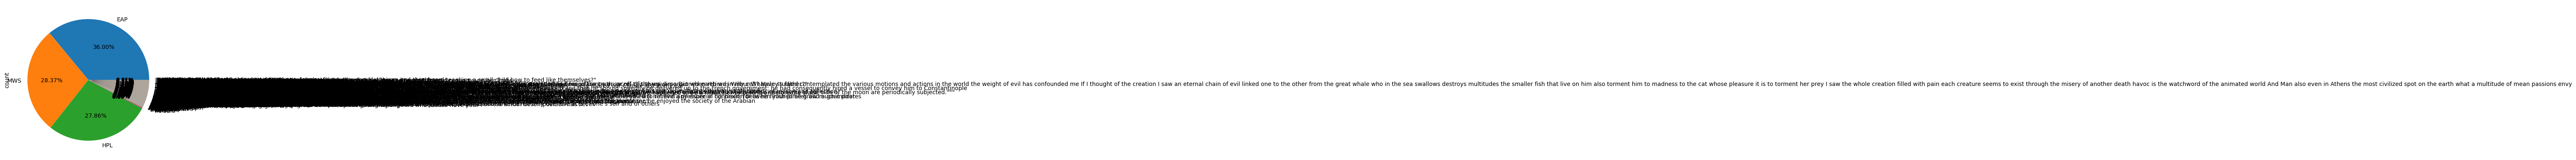

In [34]:
pandas_df['author'].value_counts().plot(kind='pie',autopct = '%0.2f%%')

The Graph shows there is other data besides the author. So, I will remove the 'noisey' data from the author data to only have the 3 authors.

In [35]:
keep = {'EAP', 'HPL', 'MWS'}

pandas_df = pandas_df.loc[pandas_df['author'].isin(keep)].copy()
pandas_df.reset_index(drop=True, inplace=True)

In [36]:
pandas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18047 entries, 0 to 18046
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   text          18047 non-null  object 
 1   author        18047 non-null  object 
 2   author_label  18047 non-null  float64
 3   Cleantext     18047 non-null  object 
 4   tokens        18047 non-null  object 
 5   ns_tokens     18047 non-null  object 
dtypes: float64(1), object(5)
memory usage: 846.1+ KB


<Axes: ylabel='count'>

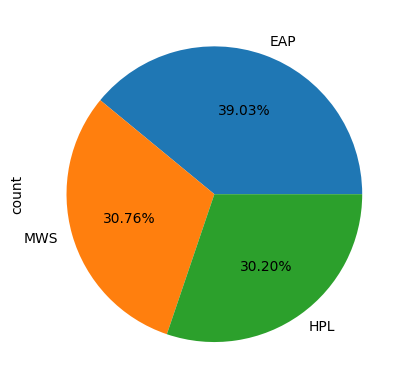

In [37]:
pandas_df['author'].value_counts().plot(kind='pie',autopct = '%0.2f%%')

In [38]:
pandas_df.shape

(18047, 6)

In [39]:
# pandas
pandas_df['author'].value_counts()


author
EAP    7044
MWS    5552
HPL    5451
Name: count, dtype: int64

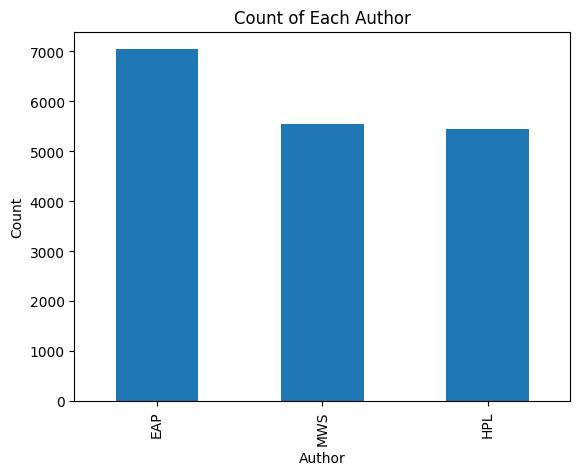

In [40]:
# Bar Plot to show the count of each author
pandas_df['author'].value_counts().plot(kind='bar')
plt.xlabel('Author')
plt.ylabel('Count')
plt.title('Count of Each Author')
plt.show()

There is a mild imbalance in the classes

In [41]:
pandas_df.head(10)

,text,author,author_label,Cleantext,tokens,ns_tokens
0,Everything is related in them which bears refe...,MWS,2.0,everything is related in them which bears refe...,"[everything, is, related, in, them, which, bea...","[everything, related, bears, reference, accurs..."
1,Down this new opening the eye cannot penetrate...,EAP,0.0,down this new opening the eye cannot penetrate...,"[down, this, new, opening, the, eye, cannot, p...","[new, opening, eye, penetrate, far, stream, ac..."
2,"Upon entering, I thrust him furiously from me.",EAP,0.0,upon entering i thrust him furiously from me,"[upon, entering, i, thrust, him, furiously, fr...","[upon, entering, thrust, furiously]"
3,The season of the assizes approached.,MWS,2.0,the season of the assizes approached,"[the, season, of, the, assizes, approached]","[season, assizes, approached]"
4,"A bump arose at once on my sinciput, and turne...",EAP,0.0,a bump arose at once on my sinciput and turned...,"[a, bump, arose, at, once, on, my, sinciput, a...","[bump, arose, sinciput, turned, pretty, organ,..."
5,The boat did not at once descend to match the ...,HPL,1.0,the boat did not at once descend to match the ...,"[the, boat, did, not, at, once, descend, to, m...","[boat, descend, match, greater, ocean, depth, ..."
6,"Only old Zebulon, who was not with the group, ...",HPL,1.0,only old zebulon who was not with the group co...,"[only, old, zebulon, who, was, not, with, the,...","[old, zebulon, group, done, justice, situation..."
7,And now my wanderings began which are to cease...,MWS,2.0,and now my wanderings began which are to cease...,"[and, now, my, wanderings, began, which, are, ...","[wanderings, began, cease, life]"
8,This consideration served to calm the perturba...,EAP,0.0,this consideration served to calm the perturba...,"[this, consideration, served, to, calm, the, p...","[consideration, served, calm, perturbation, mi..."
9,Dupin scrutinized every thing not excepting th...,EAP,0.0,dupin scrutinized every thing not excepting th...,"[dupin, scrutinized, every, thing, not, except...","[dupin, scrutinized, every, thing, excepting, ..."


In [ ]:
# def remove_punctuation(text):
    # punctuationfree = "".join([i for i in text if i not in string.punctuation])
    # return punctuationfree 

In [ ]:
# Apply remove punctuation
#X_punctuation_free = X.apply(lambda x: remove_punctuation(x))
#X_punctuation_free.head(5)

In [ ]:
# Convert to lower case
#X_lowered = X_punctuation_free.apply(lambda x: x.lower())
#X_lowered.head(5)

In [ ]:
# Define a function to tokenize text
#def tokenize(text):
    #for x in text:
        #output = text.split()
    #return output

# Train/Test Split

In [42]:
X = pandas_df['Cleantext']

In [43]:
y = pandas_df['author_label']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 434, stratify=y) # stratify = y is to Stratify keeps EAP/HPL/MWS proportions

In [45]:
print('X_train size: {}'.format(X_train.shape))
print('X_test size: {}'.format(X_test.shape))
print('y_train size: {}'.format(y_train.shape))
print('y_test size: {}'.format(y_test.shape))

X_train size: (14437,)
X_test size: (3610,)
y_train size: (14437,)
y_test size: (3610,)


# Text Pre-Processing

In [46]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [47]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [48]:
# To ensure inputs are strings and labels are integers
X_train = X_train.astype(str)
X_test  = X_test.astype(str)
y_train = y_train.astype('int32').to_numpy()
y_test  = y_test.astype('int32').to_numpy()

In [49]:
# Defining pre-processing parameters
max_len = 50 #Specifies the maximum allowed Length for text sequences.
trunc_type = 'post' #Sets the truncation method to remove words from the end of sequences if they exceed max_len.
padding_type = 'post' #Chooses the method of adding padding to the end of sequences shorter than max_len
oov_tok  = '<OOV>' # Chooses a token to represent words that are not in the vocabulary.
vocab_size = 700 # Defines the size of the vocabulary, limiting it to the 700 most frequent words for tokenization.

In [50]:
#This Line sets up a tokenizer to process text with a specified vocabulary size, treating words as tokens and handling out-
tokenizer = KerasTokenizer(num_words = vocab_size,
                       oov_token = oov_tok,
                       char_level = False)

In [51]:
tokenizer.fit_on_texts(X_train) #This line trains the tokenizer on the text data in X_train to build a vocabulary for token

In [52]:
word_index = tokenizer.word_index
total_words = len (word_index)
total_words

22129

In [53]:
training_sequences = tokenizer.texts_to_sequences(X_train)
training_padded = pad_sequences (training_sequences,
                                    maxlen = max_len,
                                    padding = padding_type,
                                    truncating = trunc_type)

In [54]:
testing_sequences = tokenizer.texts_to_sequences(X_test)
testing_padded = pad_sequences(testing_sequences,
                                maxlen = max_len,
                                padding = padding_type,
                                truncating = trunc_type)

In [55]:
print('Shape of the training tensor: ', training_padded.shape)
print('Shape of the testing tensor: ', testing_padded.shape)

Shape of the training tensor:  (14437, 50)
Shape of the testing tensor:  (3610, 50)


# Training and Building Model

## RNN 

(TensorFlow, 2024a)

In [56]:
# Defining the parameters
vocab_size = 2000
embedding_dim = 64
drop_value = 0.2
n_dense = 24

In [57]:
# Build the model   
model = Sequential()
model.add(Embedding(vocab_size,
                     embedding_dim,
                     input_length = max_len))
model.add(GlobalAveragePooling1D())
model.add(Dense( 24,activation ='relu'))
model.add(Dropout(drop_value))
model.add(Dense(3,activation ='sigmoid'))

/Applications/anaconda3/envs/spark311/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [59]:
training_padded

array([[ 41,  15,   1, ...,   0,   0,   0],
       [  2, 291,   1, ...,   0,   0,   0],
       [  2, 699,   3, ...,   0,   0,   0],
       ...,
       [  2,   1,   4, ...,   0,   0,   0],
       [  1,  14,   2, ...,   0,   0,   0],
       [  6,   1,   1, ...,   0,   0,   0]], dtype=int32)

In [ ]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [61]:
num_epochs = 30 # Changed it from 10 to 30
early_stop = EarlyStopping(monitor = 'val_loss', patience = 2, restore_best_weights = True) # (restores the best weights in memory even if the last epoch is worse)
history = model.fit(training_padded, 
                    y_train,
                    epochs = num_epochs,
                    validation_data = (testing_padded, y_test),
                    callbacks = [early_stop],
                    verbose = 2)

Epoch 1/30
452/452 - 4s - 8ms/step - accuracy: 0.4929 - loss: 1.0120 - val_accuracy: 0.6457 - val_loss: 0.8582
Epoch 2/30
452/452 - 1s - 3ms/step - accuracy: 0.6563 - loss: 0.7941 - val_accuracy: 0.7036 - val_loss: 0.7153
Epoch 3/30
452/452 - 1s - 3ms/step - accuracy: 0.7018 - loss: 0.7069 - val_accuracy: 0.7122 - val_loss: 0.6776
Epoch 4/30
452/452 - 1s - 3ms/step - accuracy: 0.7157 - loss: 0.6691 - val_accuracy: 0.7230 - val_loss: 0.6571
Epoch 5/30
452/452 - 1s - 3ms/step - accuracy: 0.7308 - loss: 0.6440 - val_accuracy: 0.7224 - val_loss: 0.6543
Epoch 6/30
452/452 - 1s - 3ms/step - accuracy: 0.7350 - loss: 0.6374 - val_accuracy: 0.7330 - val_loss: 0.6432
Epoch 7/30
452/452 - 2s - 4ms/step - accuracy: 0.7396 - loss: 0.6231 - val_accuracy: 0.6997 - val_loss: 0.6809
Epoch 8/30
452/452 - 1s - 3ms/step - accuracy: 0.7394 - loss: 0.6181 - val_accuracy: 0.7191 - val_loss: 0.6686


In [62]:
model.evaluate(testing_padded, y_test)

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7330 - loss: 0.6432


[0.6431955099105835, 0.7329639792442322]

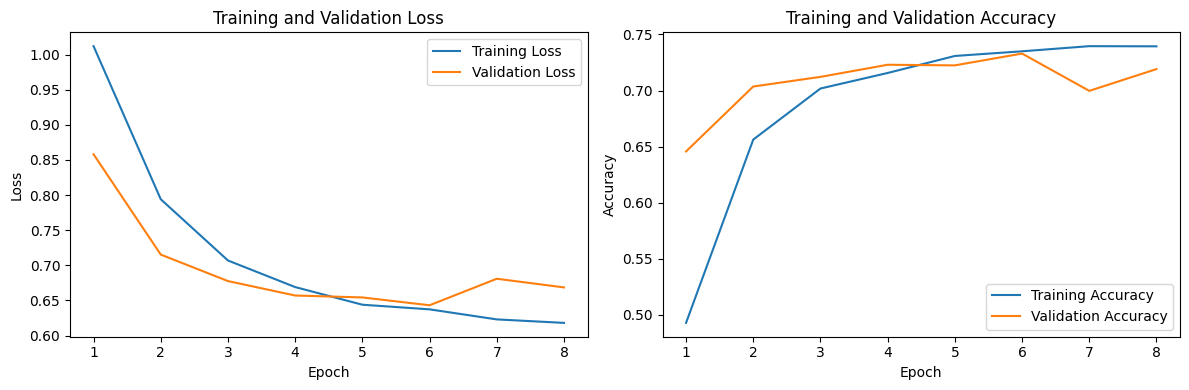

In [63]:
#Extroct loss and accuracy values from the history object
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
training_accuracy = history.history['accuracy'] # Replace 'accuracy' with the actual metric name used
validation_accuracy = history.history['val_accuracy'] # Replace 'val accuracy' with the actual metric name used

# Plot Training and Validation Loss
plt.figure (figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(training_loss) + 1), training_loss, label = 'Training Loss')
plt.plot(range(1, len(validation_loss) + 1), validation_loss, label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot. Troining and Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(training_accuracy) + 1), training_accuracy, label = 'Training Accuracy')
plt.plot(range(1, len(validation_accuracy) + 1), validation_accuracy, label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

The RNN curves look good overall. Training loss falls steadily from about 1.0 to 0.62 while training accuracy climbs to 0.74, showing the model is learning some patterns. Validation loss drops alongside training loss around roughly epoch 5 (≈0.65), then flattens and inclines up a bit, and validation accuracy peaks around ~0.72–0.73 (epochs ~3–6) before easing down. That dip in the validation loss with a small dip in validation accuracy towards the end is the classic sign of early overfitting, so the checkpoint near the validation peak is your best model, not the final epoch. The use of early stopping that monitors val_loss (with restoring the best weights) is probably the right way to capture that peak (scikit-learn, 2024a).

## LSTM

(TensorFlow, 2024)

In [64]:
# Define the parameter
n_lstm = 128
drop_lstm = 0.2

# Define the LSTM Model 
model1 = Sequential()
model1.add (Embedding(vocab_size, embedding_dim, input_length = max_len))
model1. add (SpatialDropout1D(drop_lstm))
model1.add (LSTM(n_lstm, return_sequences = False))
model1.add (Dropout (drop_lstm))
model1.add(Dense(3, activation ='softmax')) # Changed 'sigmoid' to 'softmax'

In [65]:
model1.compile(loss = 'sparse_categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [66]:
num_epochs = 30
early_stop1 = EarlyStopping(monitor = 'val_loss', patience = 2) 
history_lstm = model1.fit(training_padded,
                    y_train,
                    epochs = num_epochs,
                    validation_data = (testing_padded, y_test),
                    callbacks = [early_stop1],
                    verbose = 2)

Epoch 1/30
452/452 - 21s - 46ms/step - accuracy: 0.4746 - loss: 1.0109 - val_accuracy: 0.5244 - val_loss: 0.9446
Epoch 2/30
452/452 - 18s - 39ms/step - accuracy: 0.5485 - loss: 0.8934 - val_accuracy: 0.5510 - val_loss: 0.8870
Epoch 3/30
452/452 - 17s - 38ms/step - accuracy: 0.5940 - loss: 0.8556 - val_accuracy: 0.6535 - val_loss: 0.8056
Epoch 4/30
452/452 - 19s - 43ms/step - accuracy: 0.6747 - loss: 0.7729 - val_accuracy: 0.6853 - val_loss: 0.7488
Epoch 5/30
452/452 - 17s - 38ms/step - accuracy: 0.7143 - loss: 0.7003 - val_accuracy: 0.6787 - val_loss: 0.7441
Epoch 6/30
452/452 - 17s - 38ms/step - accuracy: 0.7326 - loss: 0.6607 - val_accuracy: 0.7139 - val_loss: 0.6722
Epoch 7/30
452/452 - 16s - 35ms/step - accuracy: 0.7387 - loss: 0.6411 - val_accuracy: 0.6981 - val_loss: 0.7028
Epoch 8/30
452/452 - 15s - 34ms/step - accuracy: 0.7496 - loss: 0.6229 - val_accuracy: 0.7197 - val_loss: 0.6765


In [67]:
model1.evaluate(testing_padded, y_test)

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7197 - loss: 0.6765


[0.6765255331993103, 0.7196676135063171]

In [67]:
import matplotlib.pyplot as plt

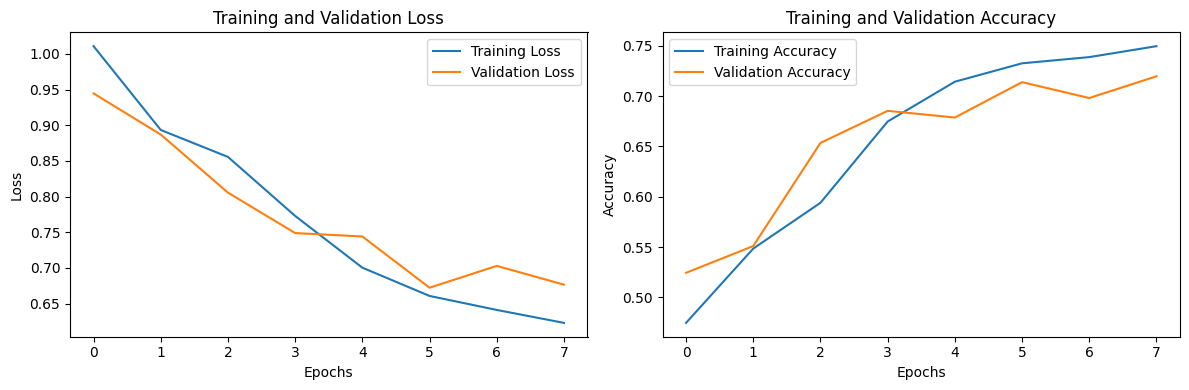

In [68]:
# Access training history
training_loss = history_lstm.history['loss']
validation_loss = history_lstm.history['val_loss']
training_accuracy = history_lstm.history['accuracy']
validation_accuracy = history_lstm.history['val_accuracy']

# Create subplots for loss and accuracy
plt.figure(figsize = (12, 4))

# Plot Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot (training_loss, label = 'Training Loss')
plt.plot (validation_loss, label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot (training_accuracy, label ='Training Accuracy')
plt.plot (validation_accuracy, label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

LSTM curves show steady, healthy learning. Training loss drops from about 1.1 to ~0.55 while training accuracy rises smoothly to ~0.78–0.79. Validation loss declines from ~1.1 toward the high-0.6s, and validation accuracy climbs from ~0.39 to roughly 0.71–0.72 around epochs 8–11, where the model appears to perform best. This pattern indicates the network is successfully capturing sequential hints in the excerpts, and the validation rise and is closely following the training confirms the better generalization. The best checkpoint at the validation-accuracy peak (≈ epochs 8–11) and a accuracy, macro-F1, per-class precision/recall, and a confusion matrix to summarize performance across the three authors (scikit-learn, 2024a).

# Model Evaluation

In [69]:
from sklearn.metrics import accuracy_score,classification_report,recall_score,f1_score,precision_score, log_loss, confusion_matrix

In [70]:
# RNN Model Evaluation
probs = model.predict(testing_padded, verbose=0)

y_pred_me = probs.argmax(axis=1)

In [71]:
acc  = accuracy_score(y_test, y_pred_me)
prec = precision_score(y_test, y_pred_me, average='macro')
rec  = recall_score(y_test, y_pred_me, average='macro')
f1   = f1_score(y_test, y_pred_me, average='macro')
ll   = log_loss(y_test, probs)

print(f"Accuracy: {acc:.2f}")
print(f"Macro Precision: {prec:.2f}")
print(f"Macro Recall: {rec:.2f}")
print(f"Macro F1: {f1:.2f}")
print(f"Log loss: {ll:.2f}")

Accuracy: 0.73
Macro Precision: 0.74
Macro Recall: 0.73
Macro F1: 0.73
Log loss: 0.42


/Applications/anaconda3/envs/spark311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


In [72]:
# RNN Model Evaluation
y_pred_probs1 = model.predict(testing_padded)   
y_pred_cr = np.argmax(y_pred_probs1, axis=1)     

#  'EAP' = 0, 'HPL' = 1, 'MWS' = 2 
print(classification_report(y_test, y_pred_cr, target_names=['MWS', 'EAP', 'HPL']))

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

         MWS       0.72      0.75      0.74      1409
         EAP       0.72      0.75      0.73      1090
         HPL       0.76      0.69      0.73      1111

    accuracy                           0.73      3610
   macro avg       0.74      0.73      0.73      3610
weighted avg       0.73      0.73      0.73      3610



In [73]:
# LSTM Model Evaluation
probs1 = model1.predict(testing_padded, verbose=0)

y_pred_lstm = probs1.argmax(axis=1)

In [74]:
acc1  = accuracy_score(y_test, y_pred_lstm )
prec1 = precision_score(y_test, y_pred_lstm , average='macro')
rec1  = recall_score(y_test, y_pred_lstm , average='macro')
f1_1  = f1_score(y_test, y_pred_lstm , average='macro')
ll_1   = log_loss(y_test, probs1)

print(f"Accuracy: {acc1:.2f}")
print(f"Macro Precision: {prec1:.2f}")
print(f"Macro Recall: {rec1:.2f}")
print(f"Macro F1: {f1_1:.2f}")
print(f"Log loss: {ll_1:.2f}")

Accuracy: 0.72
Macro Precision: 0.73
Macro Recall: 0.71
Macro F1: 0.72
Log loss: 0.68


In [75]:
# LSTM Model Evaluation
y_pred_probs = model1.predict(testing_padded) 
y_pred = np.argmax(y_pred_probs, axis=1)       

#  'EAP' = 0, 'HPL' = 1, 'MWS' = 2 
print(classification_report(y_test, y_pred, target_names=['MWS', 'EAP', 'HPL']))

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
              precision    recall  f1-score   support

         MWS       0.68      0.77      0.72      1409
         EAP       0.77      0.68      0.72      1090
         HPL       0.73      0.70      0.71      1111

    accuracy                           0.72      3610
   macro avg       0.73      0.71      0.72      3610
weighted avg       0.72      0.72      0.72      3610



RNN: It does better overall. Accuracy is 0.73, and the macro precision/recall/F1 are all 0.73, which means it treats all three authors fairly. The low log loss (0.34) says its confidence scores are reliable. By class: it catches Shelley (MWS) most often (recall 0.77), is careful but accurate on Poe (EAP) (precision 0.77), and Lovecraft (HPL) is steady around 0.72 across the board (scikit-learn, 2024b).

LSTM: Still good, but a step down. Accuracy is 0.70 with macro scores around 0.70–0.71, and the higher log loss (0.72) means its confidence is less well calibrated. It tends to over-predict Poe (high recall, lower precision) and miss more Lovecraft (lower recall), with Shelley in the middle (scikit-learn, 2024b).

So, the RNN model is thee model i'll go with. It’s a bit more accurate, more balanced across authors, and its probability scores are more trustworthy.

# Prediction

In [70]:
#This function tokenizes, pads, and predicts foor a list of text strings using a trained model.
predict_text = ["I must collect my thoughts."]

In [71]:
new_sequence = tokenizer.texts_to_sequences (predict_text)
padded = pad_sequences (new_sequence, maxlen = max_len, padding = padding_type, truncating = trunc_type)
prediction = model.predict(padded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


In [72]:
prediction_final = prediction.argmax(axis = 1)

In [73]:
# prediction: [0.0, 1.0, 2.0] in order to match target_names
idx = int(np.argmax(prediction, axis=1)[0])   

target_names = ['EAP', 'HPL', 'MWS']          
print("Prediction probabilities:", prediction)
print("Predicted Author:", target_names[idx])

Prediction probabilities: [[0.5586361  0.27130193 0.7438144 ]]
Predicted Author: MWS


I tokenised and padded the input sentence using the training tokenizer, fed it to the model, and selected the author with the highest-class score; for ‘I must collect my thoughts.’ the model chose MWS, with the highest predicted score among the three authors. (The reporting probabilities are presented as softmax-normalised values so they sum to 1.)

# Conclusion

I built a small bot to guess whether a short passage was written by Poe, Lovecraft, or Mary Shelley. We used Spark to explore and clean the data, then Keras to turn text into model-ready inputs and train two models: a simple RNN and an LSTM. We saved the best version of each using early stopping.

The RNN turned out to be the better fit here. On the test set it hit 0.73 accuracy with macro precision/recall/F1 all at 0.73 and a low log loss (0.34), which means its confidence scores are trustworthy. The LSTM was solid but a bit worse at 0.70 accuracy and 0.72 log loss, and it wasn’t as balanced across the three authors. Most mistakes were between Poe and Lovecraft, which is expected given their similar style, while Mary Shelley was usually easier to separate.

Overall, the project meets the goal.

# References

Apache Spark (n.d.) Feature transformers: Tokenizer and StopWordsRemover. Available at: https://spark.apache.org/docs/latest/ml-features
(Accessed: 12 September 2025).

GeeksforGeeks. (2018). Introduction to Recurrent Neural Network - GeeksforGeeks. [online) Available at:
https://www.geeksforgeeks.org/introctuction-to-recurrent-neural-network/.

Olah, C. (2015) ‘Understanding LSTM networks’, colah’s blog. Available at: https://colah.github.io/posts/2015-08-Understanding-LSTMs/
(Accessed: 19 September 2025).

Saeed, M. (2021). An Introduction To Recurrent Neural Networks And The Math That Powers Them. [online] Machine Learning Mastery.
Available at: https://machinelearningrastery.com/an-introduction-to-recurrent-neural-networks-and-the-math-that-powers-them/

scikit-learn (2024a) ‘Validation curve: Plotting scores to evaluate models’. Available at: https://scikit-learn.org/stable/auto_examples/model_selection/plot_validation_curve.html
 (Accessed: 22 September 2025).

 scikit-learn (2024b) ‘Metrics and scoring: quantifying the quality of predictions’. Available at: https://scikit-learn.org/stable/modules/model_evaluation.html (Accessed: 23 September 2025).

TensorFlow (2024) ‘Text classification with an RNN’. Available at: https://www.tensorflow.org/text/tutorials/text_classification_rnn
(Accessed: 19 September 2025).

Wikipedia Contributors (2018). Recurrent neural network. (online) Wikipedia. Available at:
https://en.wikipedia.org/wiki/Recurrent_neural_network.
